 Import Dataset dan Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/test.csv')

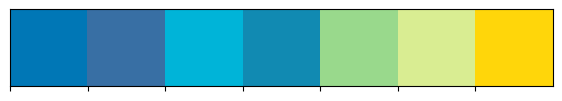

In [2]:
color = ["#0077b6", "#386fa4", "#00b4d8", "#118ab2", "#99d98c", "#d9ed92", "#ffd60a"]

df_style = {
    "border" : "1px solid black",
    "border-collapse" : "collapse",
    "font-size" : "14px",
    "color" : "white",
    "padiing" : "4px",
    "text-align" : "center",
    "background-color": color[3]
}

table_style = [
    {'selector': 'th', 'props': [('background-color', color[0]), ('border', '1px solid black'), ('color', 'white')]},
    {'selector': 'th.col_heading', 'props': [('background-color', color[0]), ('border', '1px solid black'), ('color', 'white'), ('padding', '4px')]},
    {'selector': 'th.row_heading', 'props': [('background-color', color[0]), ('border', '1px solid black'), ('color', 'white'), ('padding', '4px')]},
    {'selector': 'tr:nth-child(even) td', 'props': [('background-color', color[2])]},
    {'selector': 'tr:nth-child(odd) td', 'props': [('background-color', color[1])]},
    {'selector': 'td', 'props': [('border', '1px solid black')]},
]

sns.palplot(sns.color_palette(color))

# 1. EDA

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25976 entries, 0 to 25975
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         25976 non-null  int64  
 1   id                                 25976 non-null  int64  
 2   Gender                             25976 non-null  object 
 3   Customer Type                      25976 non-null  object 
 4   Age                                25976 non-null  int64  
 5   Type of Travel                     25976 non-null  object 
 6   Class                              25976 non-null  object 
 7   Flight Distance                    25976 non-null  int64  
 8   Inflight wifi service              25976 non-null  int64  
 9   Departure/Arrival time convenient  25976 non-null  int64  
 10  Ease of Online booking             25976 non-null  int64  
 11  Gate location                      25976 non-null  int

In [4]:
df.head().style.set_properties(**df_style).set_table_styles(table_style)

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,3,4,3,4,3,5,5,5,5,2,5,5,50,44.000000,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,3,1,5,4,5,4,4,4,4,3,4,5,0,0.000000,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,2,4,2,2,2,2,4,1,3,2,2,2,0,0.000000,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,0,2,3,4,4,1,1,1,1,3,1,4,0,6.000000,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,4,3,4,1,2,2,2,2,2,4,2,4,0,20.000000,satisfied


In [5]:
df = df.drop(columns=['Unnamed: 0', 'id'])
df.head().style.set_properties(**df_style).set_table_styles(table_style)

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Female,Loyal Customer,52,Business travel,Eco,160,5,4,3,4,3,4,3,5,5,5,5,2,5,5,50,44.000000,satisfied
1,Female,Loyal Customer,36,Business travel,Business,2863,1,1,3,1,5,4,5,4,4,4,4,3,4,5,0,0.000000,satisfied
2,Male,disloyal Customer,20,Business travel,Eco,192,2,0,2,4,2,2,2,2,4,1,3,2,2,2,0,0.000000,neutral or dissatisfied
3,Male,Loyal Customer,44,Business travel,Business,3377,0,0,0,2,3,4,4,1,1,1,1,3,1,4,0,6.000000,satisfied
4,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,4,3,4,1,2,2,2,2,2,4,2,4,0,20.000000,satisfied


In [6]:
df.duplicated().sum()

0

In [7]:
df.isnull().sum().to_frame().T.style.set_properties(**df_style).set_table_styles(table_style)

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,83,0


In [8]:
df.dropna(inplace=True)

In [9]:
cat_cols = df.select_dtypes(include='object').columns.to_list()
num_cols = df.select_dtypes(include='number').columns.to_list()

print(f'Categorical : {cat_cols}')
print(f'Numerical : {num_cols}')

Categorical : ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction']
Numerical : ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']


In [10]:
for col in cat_cols:
    print(f'{col} : {df[col].unique()}')

Gender : ['Female' 'Male']
Customer Type : ['Loyal Customer' 'disloyal Customer']
Type of Travel : ['Business travel' 'Personal Travel']
Class : ['Eco' 'Business' 'Eco Plus']
satisfaction : ['satisfied' 'neutral or dissatisfied']


# 2. Insight

### Cek Outlier

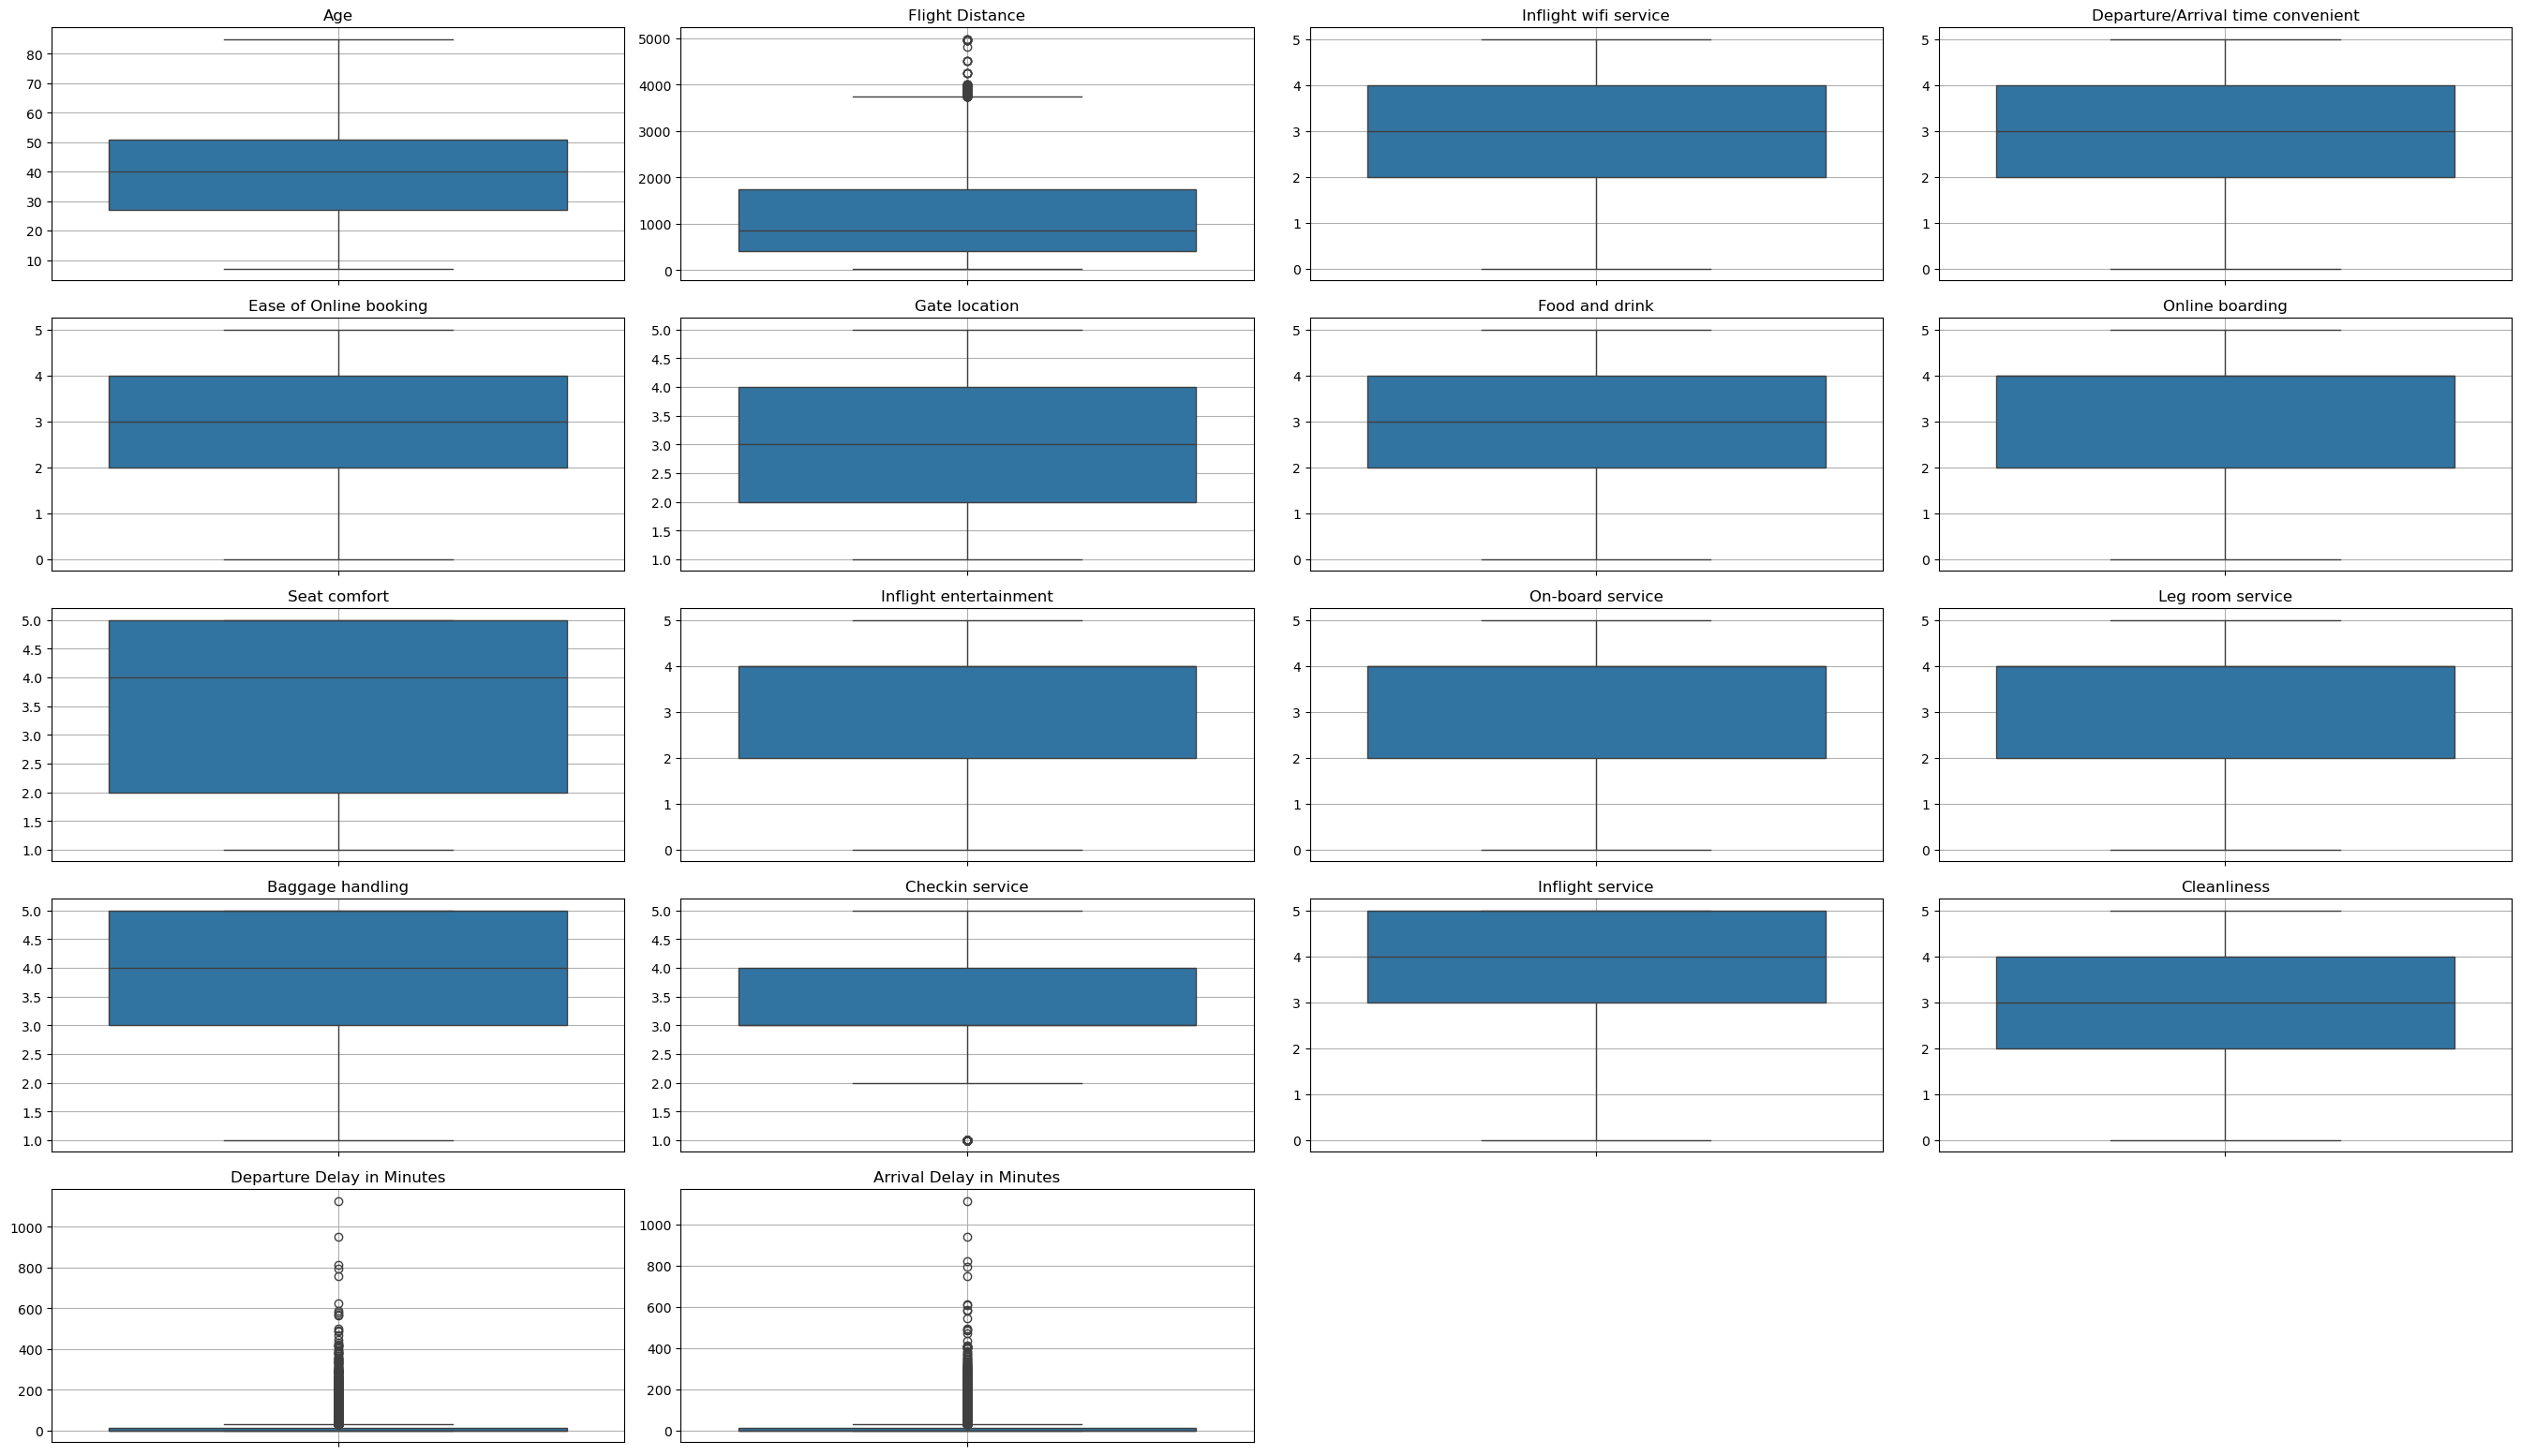

In [11]:
n_cols = 4
n_rows = int(np.ceil(len(num_cols) / 2))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_rows * 3, n_cols * 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col]

    axes[i].set_title(col.replace("_", " "))
    sns.boxplot(y=data, ax=axes[i])
    axes[i].set_ylabel(None)
    axes[i].grid(True)

for j in range(len(num_cols), n_rows * n_cols):
    plt.delaxes(axes[j])

plt.tight_layout()
plt.show()

__Hasil Analisis__ <br>
ada beberapa outlier di beberapa kolom kita akan memperbaiki ini saat data preprocessing

### Cek Imbalance Data

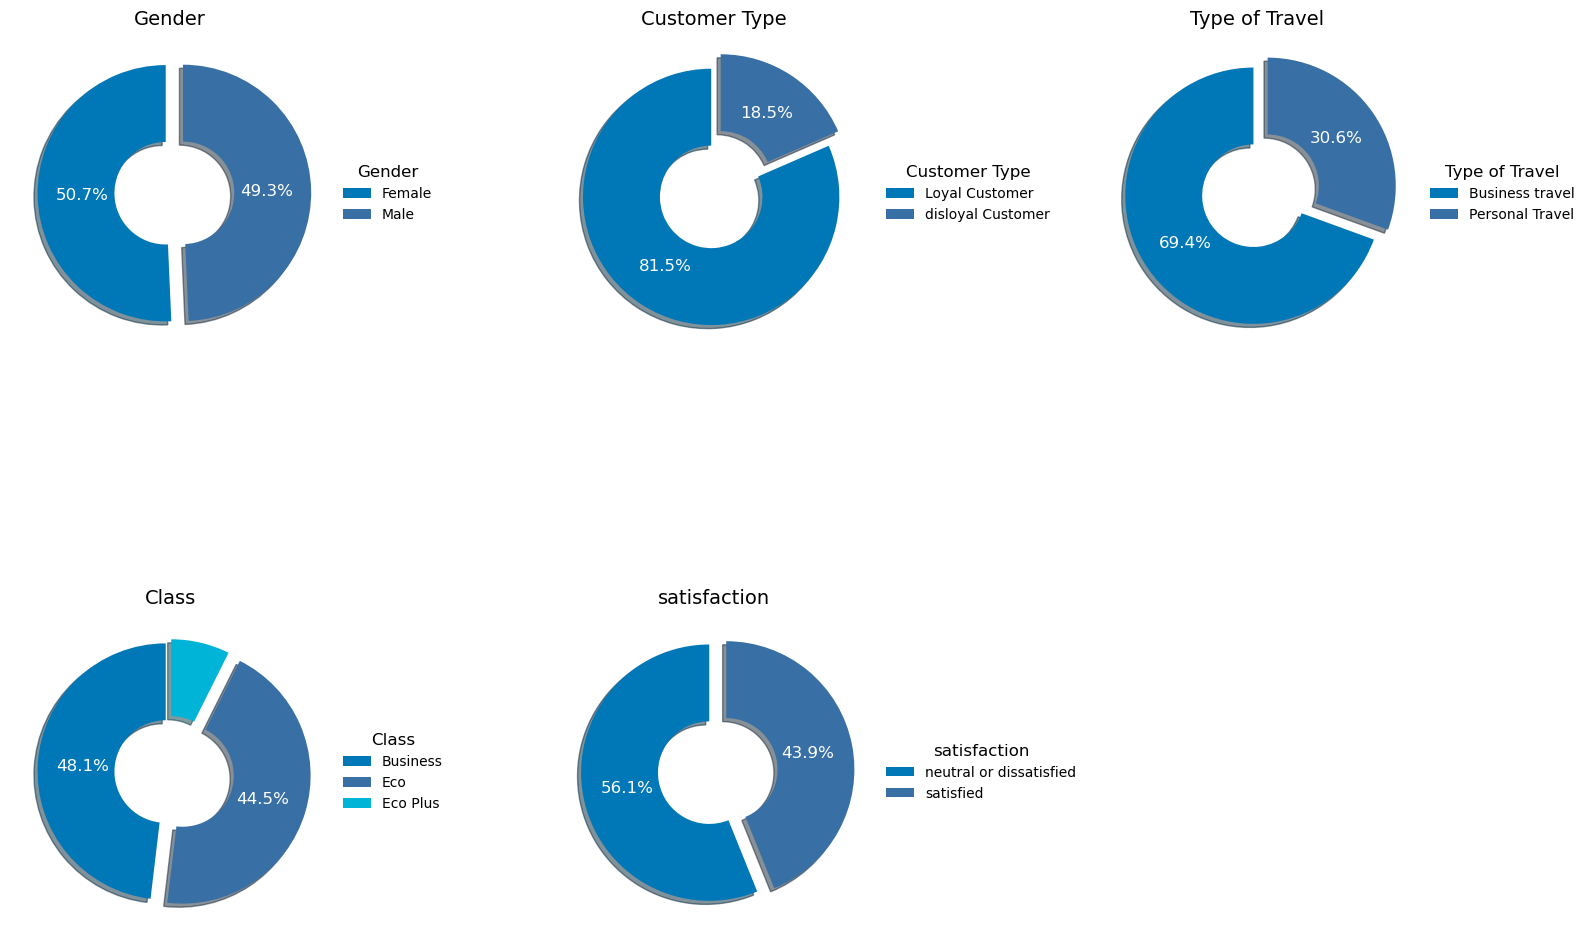

In [12]:
n_cols = 3
n_rows = int(np.ceil(len(cat_cols) / n_cols))

fig,axes = plt.subplots(n_rows, n_cols, figsize=(n_rows * 8, n_cols * 4))
axes = axes.flatten()

plot_idx = 0

for col in cat_cols:
    data = df[col].value_counts()

    wedges, text, autotexts = axes[plot_idx].pie(
        x = data,
        autopct = lambda p: f'{p:.1f}%' if p >= 10 else "",
        startangle = 90,
        colors = color,
        explode = [0.035 if i % 2 == 0 else 0.1 for i in range(len(data))],
        pctdistance = 0.65,
        wedgeprops = dict(width=0.6),
        shadow = True
    )

    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(12)

        axes[plot_idx].legend(
        wedges, data.index,
        title=col.replace("_", " "),
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        frameon=False,
        title_fontsize=12,
        fontsize=10
    )

    axes[plot_idx].set_title(col.replace("_", " "), fontsize=14)
    plot_idx += 1

for j in range(plot_idx, n_rows * n_cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
    

### Melihat Rating Kepuasan Pelanggan di setiap kelas dan Kepuasan berdasarkan Kelas Penerbangan

Visualisasi ini terdiri dari dua bagian : <br>

- Bagian kiri menunjukkan bagaimana rata-rata rating layanan diberikan oleh pelanggan berdasarkan tingkat kepuasan mereka — membandingkan antara pelanggan yang puas dengan yang tidak puas atau netral.

- Bagian kanan memperlihatkan rata-rata rating layanan dari pelanggan yang puas, namun dibedakan berdasarkan kelas penerbangan seperti Ekonomi, Ekonomi Plus, dan Bisnis.

Visualisasi ini bertujuan untuk menggali bagaimana pengalaman layanan berdampak pada kepuasan pelanggan, serta bagaimana kualitas layanan dirasakan oleh tiap segmen kelas penerbangan.

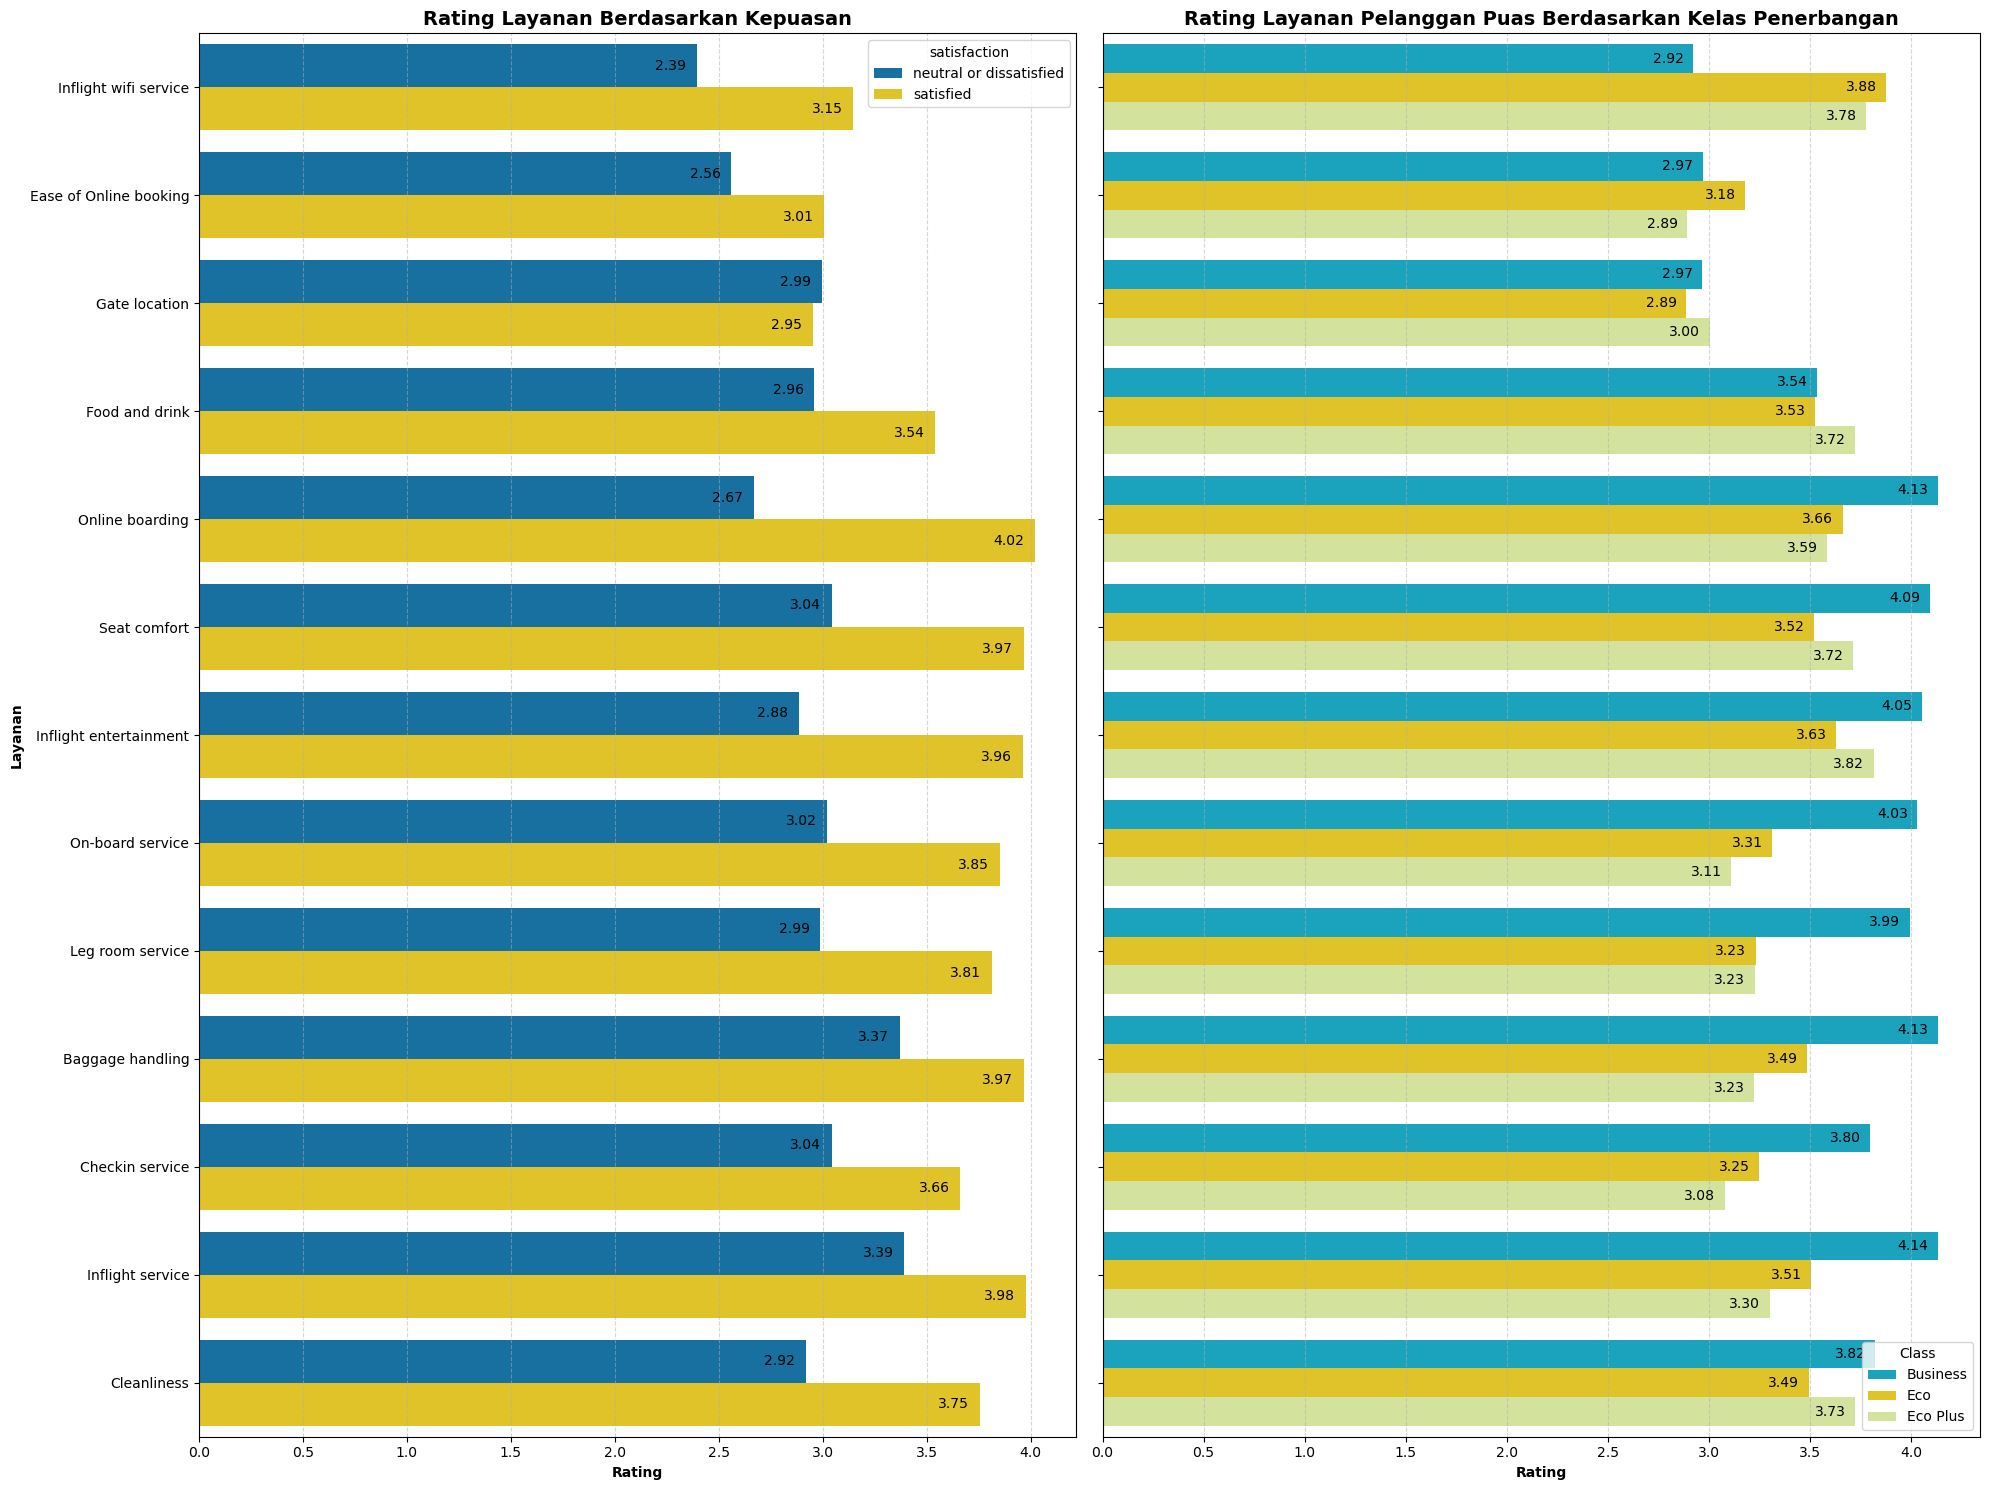

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(20, 15), sharey=True)

groupings = [
    ('satisfaction', df), 
    ('Class', df[df['satisfaction'] == 'satisfied']) 
]

service_columns = [
    'Inflight wifi service', 'Ease of Online booking', 'Gate location', 'Food and drink',
    'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service',
    'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness'
]

titles = [
    'Rating Layanan Berdasarkan Kepuasan',
    'Rating Layanan Pelanggan Puas Berdasarkan Kelas Penerbangan'
]

palettes = [[color[0], color[-1]], [color[2], color[6], color[5]]]

for i, (group_col, data_source) in enumerate(groupings):
    mean_data = data_source.groupby(group_col)[service_columns].mean().T.reset_index()
    mean_data = mean_data.rename(columns={'index': 'Service'})
    melted = mean_data.melt(id_vars='Service', var_name=group_col, value_name='Average Rating')

    ax = axes[i]
    sns.barplot(
        data=melted,
        x='Average Rating',
        y='Service',
        hue=group_col,
        ax=ax,
        palette=palettes[i]
    )
    ax.set_title(titles[i], fontsize=14, fontweight='bold')
    ax.set_xlabel('Rating', fontweight='bold')
    ax.set_ylabel('' if i > 0 else 'Layanan', fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.5)

    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.text(width - 0.2, p.get_y() + p.get_height() / 2,
                    f'{width:.2f}', ha='left', va='center', fontsize=10,)

handles, labels = axes[0].get_legend_handles_labels()

plt.tight_layout()
plt.show()


__Hasil Analisis__ <br>

1. __Layanan Sangat Berpengaruh pada Kepuasan Pelanggan__

- Pelanggan yang puas secara konsisten memberikan rating lebih tinggi di hampir semua aspek layanan.

2. __Kelas Penerbangan Mencerminkan Kualitas Layanan__

- Pelanggan kelas Business memberi rating tertinggi hampir di semua fitur layanan, terutama:

- Seat comfort, Inflight wifi service, dan Check-in service

- Kelas Eco Plus cenderung lebih mirip dengan Economy, tidak terlalu menonjol dibanding Business.

3. __Inflight Wifi Service Konsisten Mendapat Rating Terendah__

- Baik pelanggan puas maupun di kelas Business, rating untuk layanan ini tetap rendah.

- Ini menunjukkan bahwa masalah kualitas layanan internet di pesawat belum teratasi.

### Perbandingan Rata-rata Penilaian Layanan Berdasarkan Customer Type dan Jenis Perjalanan

Visualisasi ini menampilkan perbandingan skor rata-rata dari berbagai layanan penerbangan berdasarkan dua kategori pelanggan: tipe pelanggan (Customer Type) dan jenis perjalanan (Type of Travel). Setiap bar menggambarkan seberapa tinggi layanan tertentu dinilai oleh masing-masing segmen pelanggan.

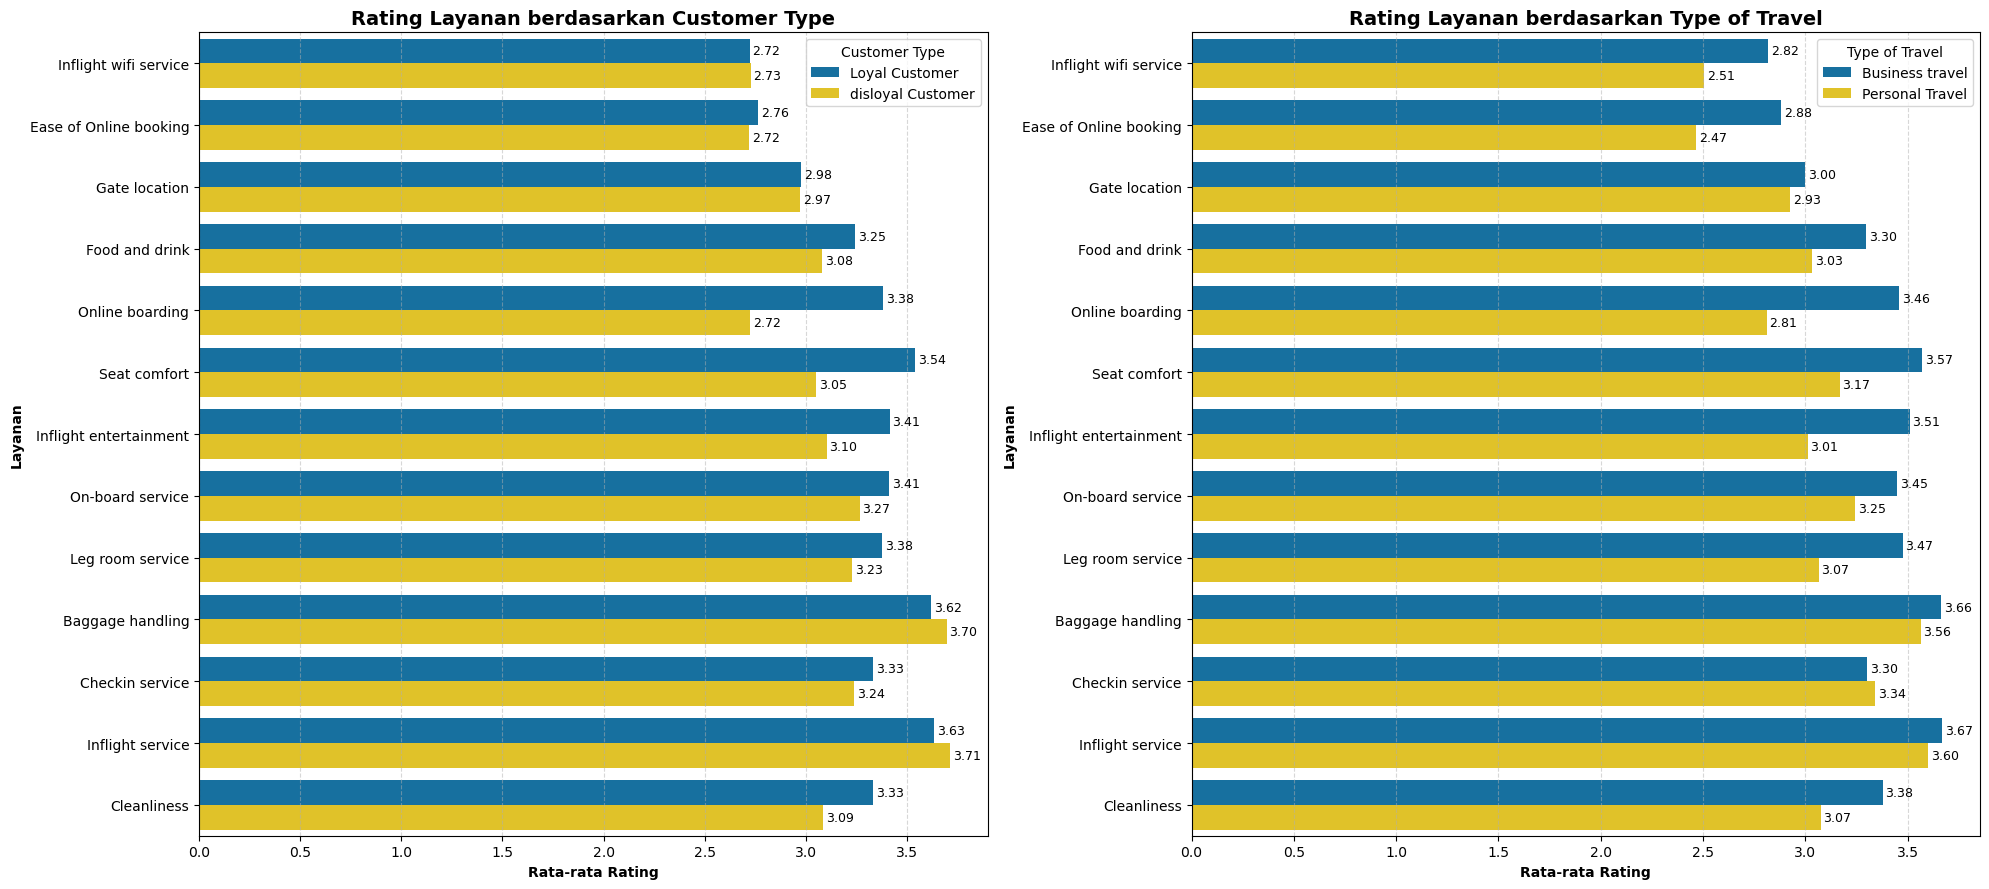

In [14]:
service_cols = [
    'Inflight wifi service', 'Ease of Online booking', 'Gate location', 'Food and drink',
    'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service',
    'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness'
]

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
group_cols = ['Customer Type', 'Type of Travel']
warna = [color[0], color[-1]]
titles = [
    'Rating Layanan berdasarkan Customer Type',
    'Rating Layanan berdasarkan Type of Travel'
]

for i, col in enumerate(group_cols):
    avg_rating = df.groupby(col)[service_cols].mean().T.reset_index()
    avg_rating = avg_rating.melt(id_vars='index', var_name=col, value_name='Average Rating')
    avg_rating = avg_rating.rename(columns={'index': 'Service'})

    ax = sns.barplot(data=avg_rating, x='Average Rating', y='Service', hue=col,
                     palette=warna, ax=axes[i])
    
    axes[i].set_title(titles[i], fontsize=14, weight='bold')
    axes[i].set_xlabel('Rata-rata Rating', fontweight='bold')
    axes[i].set_ylabel('Layanan', fontweight='bold')

    # Tambahkan label di ujung bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=2, fontsize=9)

    axes[i].grid(axis='x', linestyle='--', alpha=0.5)
    axes[i].legend(title=col)

plt.tight_layout()
plt.show()

__Hasil Analisis__

- Loyal Customer cenderung memberi skor lebih tinggi di hampir semua layanan dibandingkan disloyal.

- Business Travel cenderung lebih menuntut dan memberikan skor tinggi pada seat comfort, wifi, dan on-board service.

- Perbedaan terbesar antar segmen muncul pada fitur-fitur seperti Inflight wifi service, Seat comfort, dan Cleanliness.

### Melihat distribusi Kepuasan berdasarkan usia & gender

Visualisasi ini menunjukkan bagaimana distribusi usia pelanggan berbeda berdasarkan gender (laki-laki dan perempuan) dan tingkat kepuasan mereka (puas atau tidak puas). Histogram dibagi menjadi empat bagian: kombinasi dari jenis kelamin dan tingkat kepuasan,

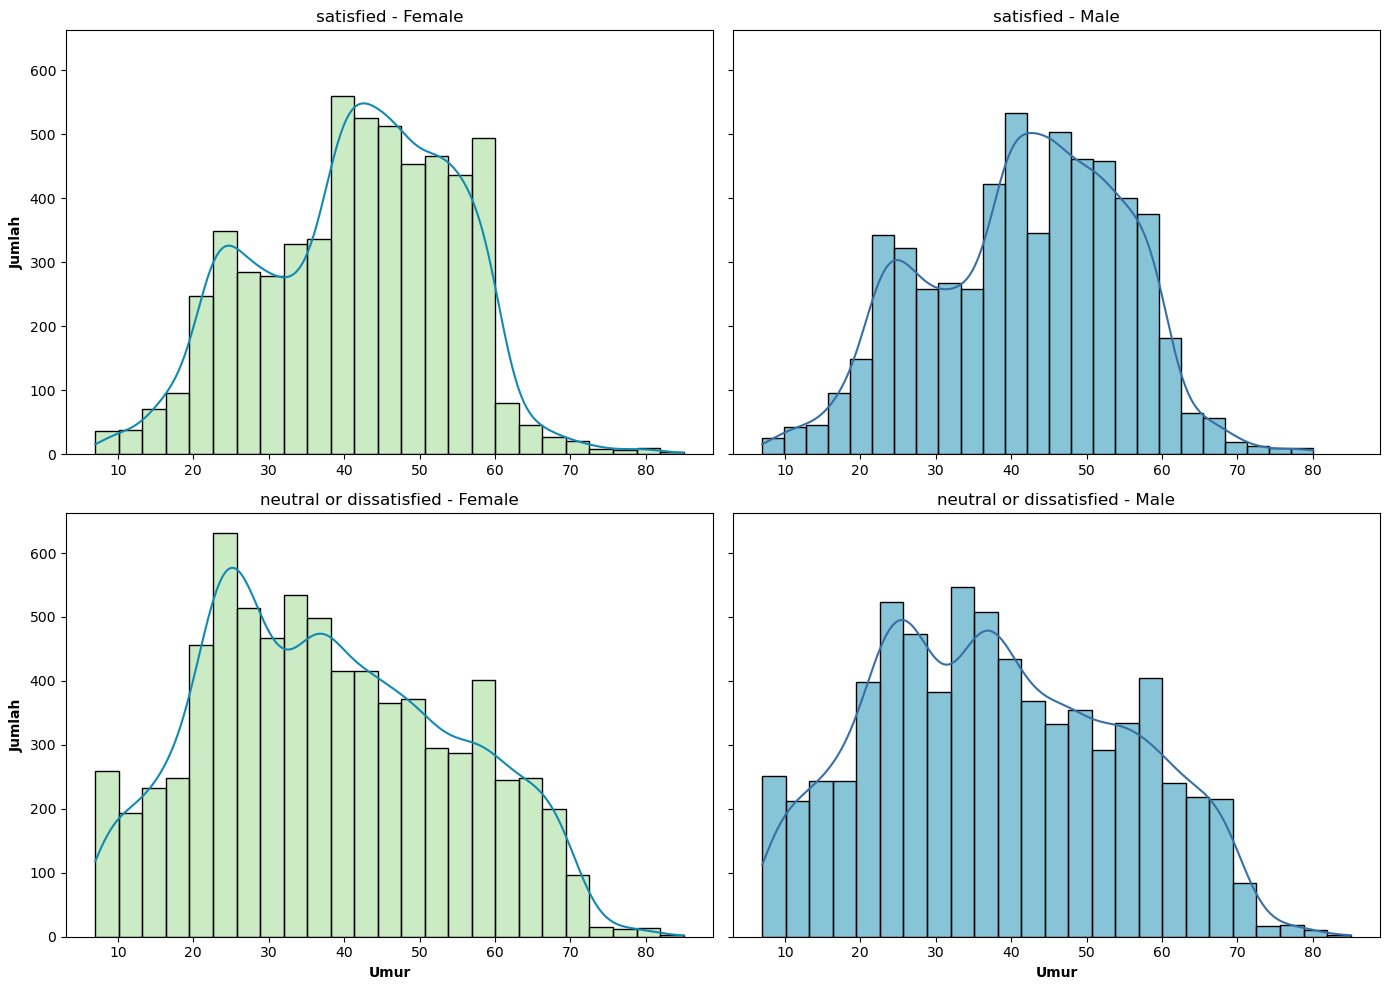

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

statisfied = ["satisfied", "neutral or dissatisfied"]
genders = ["Female", "Male"]

for i, test in enumerate(statisfied):
    test_df = df[df["satisfaction"] == test]
    for j, gender in enumerate(genders):
        ax = axes[i, j]
        color_fill = color[3] if gender == "Male" else color[4]
        color_line = color[1] if gender == "Male" else color[3]

        sns.histplot(
            test_df[test_df["Gender"] == gender]["Age"],
            color=color_fill,
            kde=True,
            bins=25,
            ax=ax
        )
        
        ax.set_ylabel("Jumlah", fontweight='bold')
        ax.set_xlabel("Umur", fontweight='bold')
        ax.lines[0].set_color(color_line)
        ax.set_title(f"{test} - {gender}")
        ax.tick_params(axis='x', which='both', labelbottom=True)

plt.tight_layout()
plt.show()


__Hasil Analisis__ 

1. __Perempuan Lebih Tua Lebih Sering Puas:__

- Kelompok perempuan dengan kepuasan tinggi (atas kiri) terlihat lebih dominan di usia 35–60 tahun. Ini bisa jadi karena ekspektasi mereka lebih realistis atau mereka lebih menghargai kenyamanan layanan.

2. __Pria Puas Tersebar Lebih Merata:__

- Laki-laki yang puas (atas kanan) memiliki distribusi yang cukup seimbang dari usia 25–60, tanpa puncak ekstrem. Mungkin menunjukkan pria cenderung punya tingkat toleransi lebih lebar terhadap layanan.

3. __Ketidakpuasan Didominasi Usia Muda:__

- Baik pria maupun wanita yang tidak puas (bawah kiri & kanan), punya puncak di usia 20–35 tahun. Artinya, pelanggan muda mungkin punya ekspektasi tinggi atau lebih sensitif terhadap kekurangan layanan.

### Pengaruh Keterlambatan dan Jarak Tempuh terhadap Kepuasan Pelanggan

Visualisasi ini menyajikan hubungan antara durasi keterlambatan dan jarak penerbangan dengan tingkat kepuasan pelanggan. Dengan mengelompokkan data berdasarkan kategori keterlambatan dan jarak tempuh, dapat terlihat pola preferensi dan toleransi pelanggan terhadap dua faktor penting dalam layanan penerbangan.

C:\Users\User\AppData\Local\Temp\ipykernel_17984\999894919.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delay_counts = df_delay.groupby(['Delay Category', 'satisfaction']).size().reset_index(name='count')
C:\Users\User\AppData\Local\Temp\ipykernel_17984\999894919.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dist_counts = df_dist.groupby(['Distance Category', 'satisfaction']).size().reset_index(name='count')


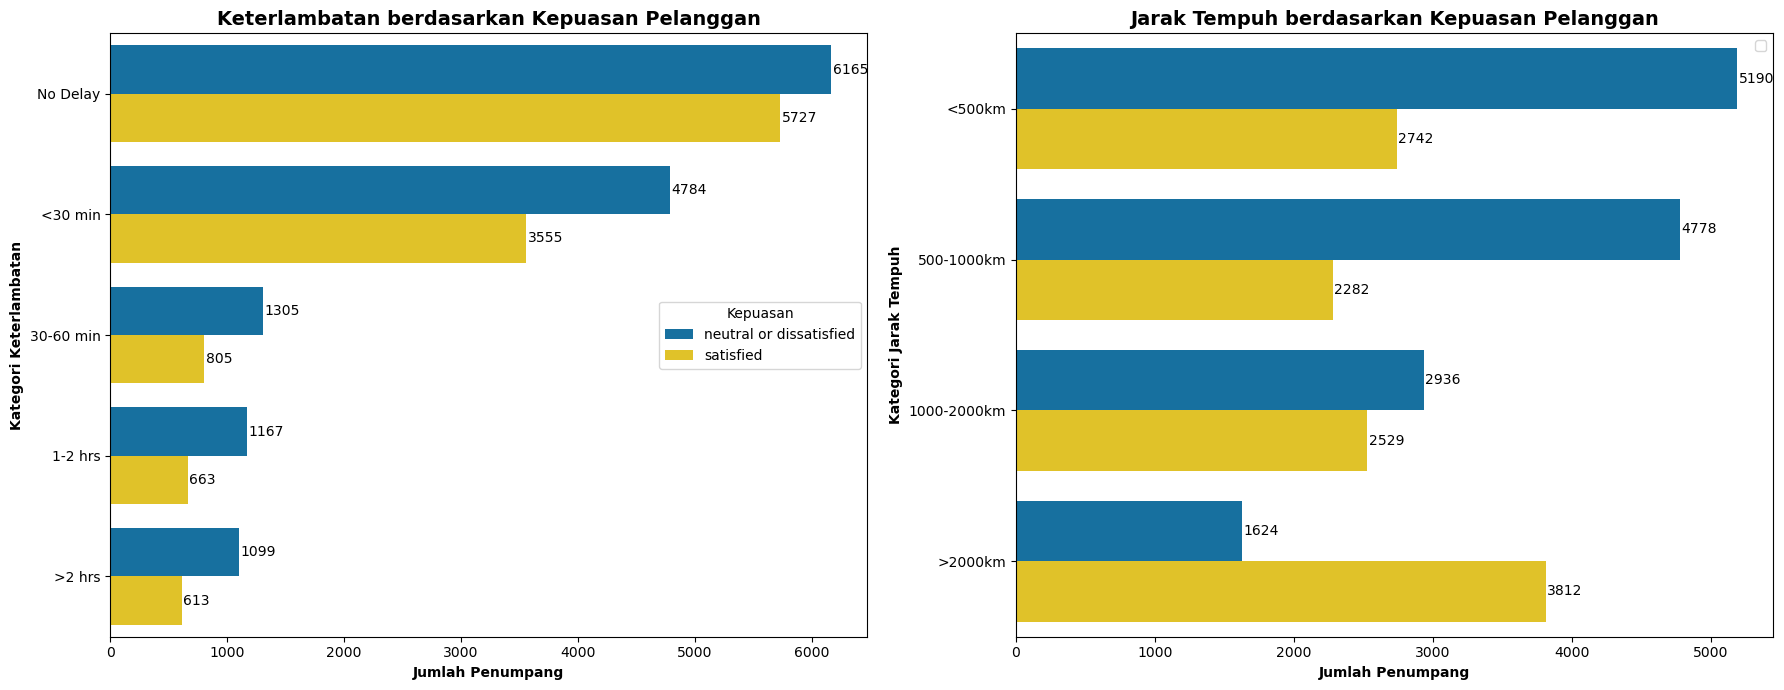

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

df_delay = df.copy()
df_delay['Total Delay'] = df_delay['Departure Delay in Minutes'] + df_delay['Arrival Delay in Minutes']
df_delay['Delay Category'] = pd.cut(df_delay['Total Delay'], bins=[-1, 0, 30, 60, 120, 1000],
                                    labels=['No Delay', '<30 min', '30-60 min', '1-2 hrs', '>2 hrs'])
delay_counts = df_delay.groupby(['Delay Category', 'satisfaction']).size().reset_index(name='count')

ax0 = sns.barplot(data=delay_counts, x='count', y='Delay Category', hue='satisfaction', ax=axes[0], palette=[color[0], color[-1]])
axes[0].set_title('Keterlambatan berdasarkan Kepuasan Pelanggan', fontsize=14, weight='bold')
axes[0].set_xlabel('Jumlah Penumpang', fontweight='bold')
axes[0].set_ylabel('Kategori Keterlambatan', fontweight='bold')
axes[0].legend(loc='center right', title='Kepuasan')
for container0 in ax0.containers:
        ax0.bar_label(container0, label_type="edge", padding=1, fontsize=10, color='black')


df_dist = df.copy()
df_dist['Distance Category'] = pd.cut(df_dist['Flight Distance'], bins=[0, 500, 1000, 2000, 5000],
                                      labels=['<500km', '500-1000km', '1000-2000km', '>2000km'])
dist_counts = df_dist.groupby(['Distance Category', 'satisfaction']).size().reset_index(name='count')

ax1 = sns.barplot(data=dist_counts, x='count', y='Distance Category', hue='satisfaction', ax=axes[1], palette=[color[0], color[-1]])
axes[1].set_title('Jarak Tempuh berdasarkan Kepuasan Pelanggan', fontsize=14, weight='bold')
axes[1].set_xlabel('Jumlah Penumpang', fontweight='bold')
axes[1].set_ylabel('Kategori Jarak Tempuh', fontweight='bold')
axes[1].legend([])
for container1 in ax1.containers:
        ax1.bar_label(container1, label_type="edge", padding=1, fontsize=10, color='black')

plt.tight_layout()
plt.show()

__Hasil Analisis__

1. __Keterlambatan dan Kepuasan:__

- Pelanggan yang tidak mengalami keterlambatan (No Delay) memiliki tingkat kepuasan yang jauh lebih tinggi dibanding kategori lainnya.

- Semakin lama keterlambatan, semakin banyak pelanggan yang tidak puas, terutama pada keterlambatan di atas 1 jam.

- Ini menunjukkan bahwa ketepatan waktu adalah faktor kunci dalam kepuasan pelanggan.

2. __Jarak Tempuh dan Kepuasan:__

- Untuk penerbangan jarak menengah hingga jauh (1000–2000 km dan >2000 km), tingkat kepuasan cenderung meningkat.

- Sebaliknya, penerbangan jarak pendek (<500 km) memiliki persentase ketidakpuasan lebih tinggi.

- Hal ini bisa mengindikasikan bahwa pelanggan lebih menghargai layanan dalam penerbangan jarak jauh, atau mungkin harapan lebih tinggi terhadap kenyamanan di penerbangan pendek tidak terpenuhi.

# 3. Data PreProcessing

### Outlier

In [17]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df_outlier = df[(df[col] >= lower) & (df[col] <= upper)]

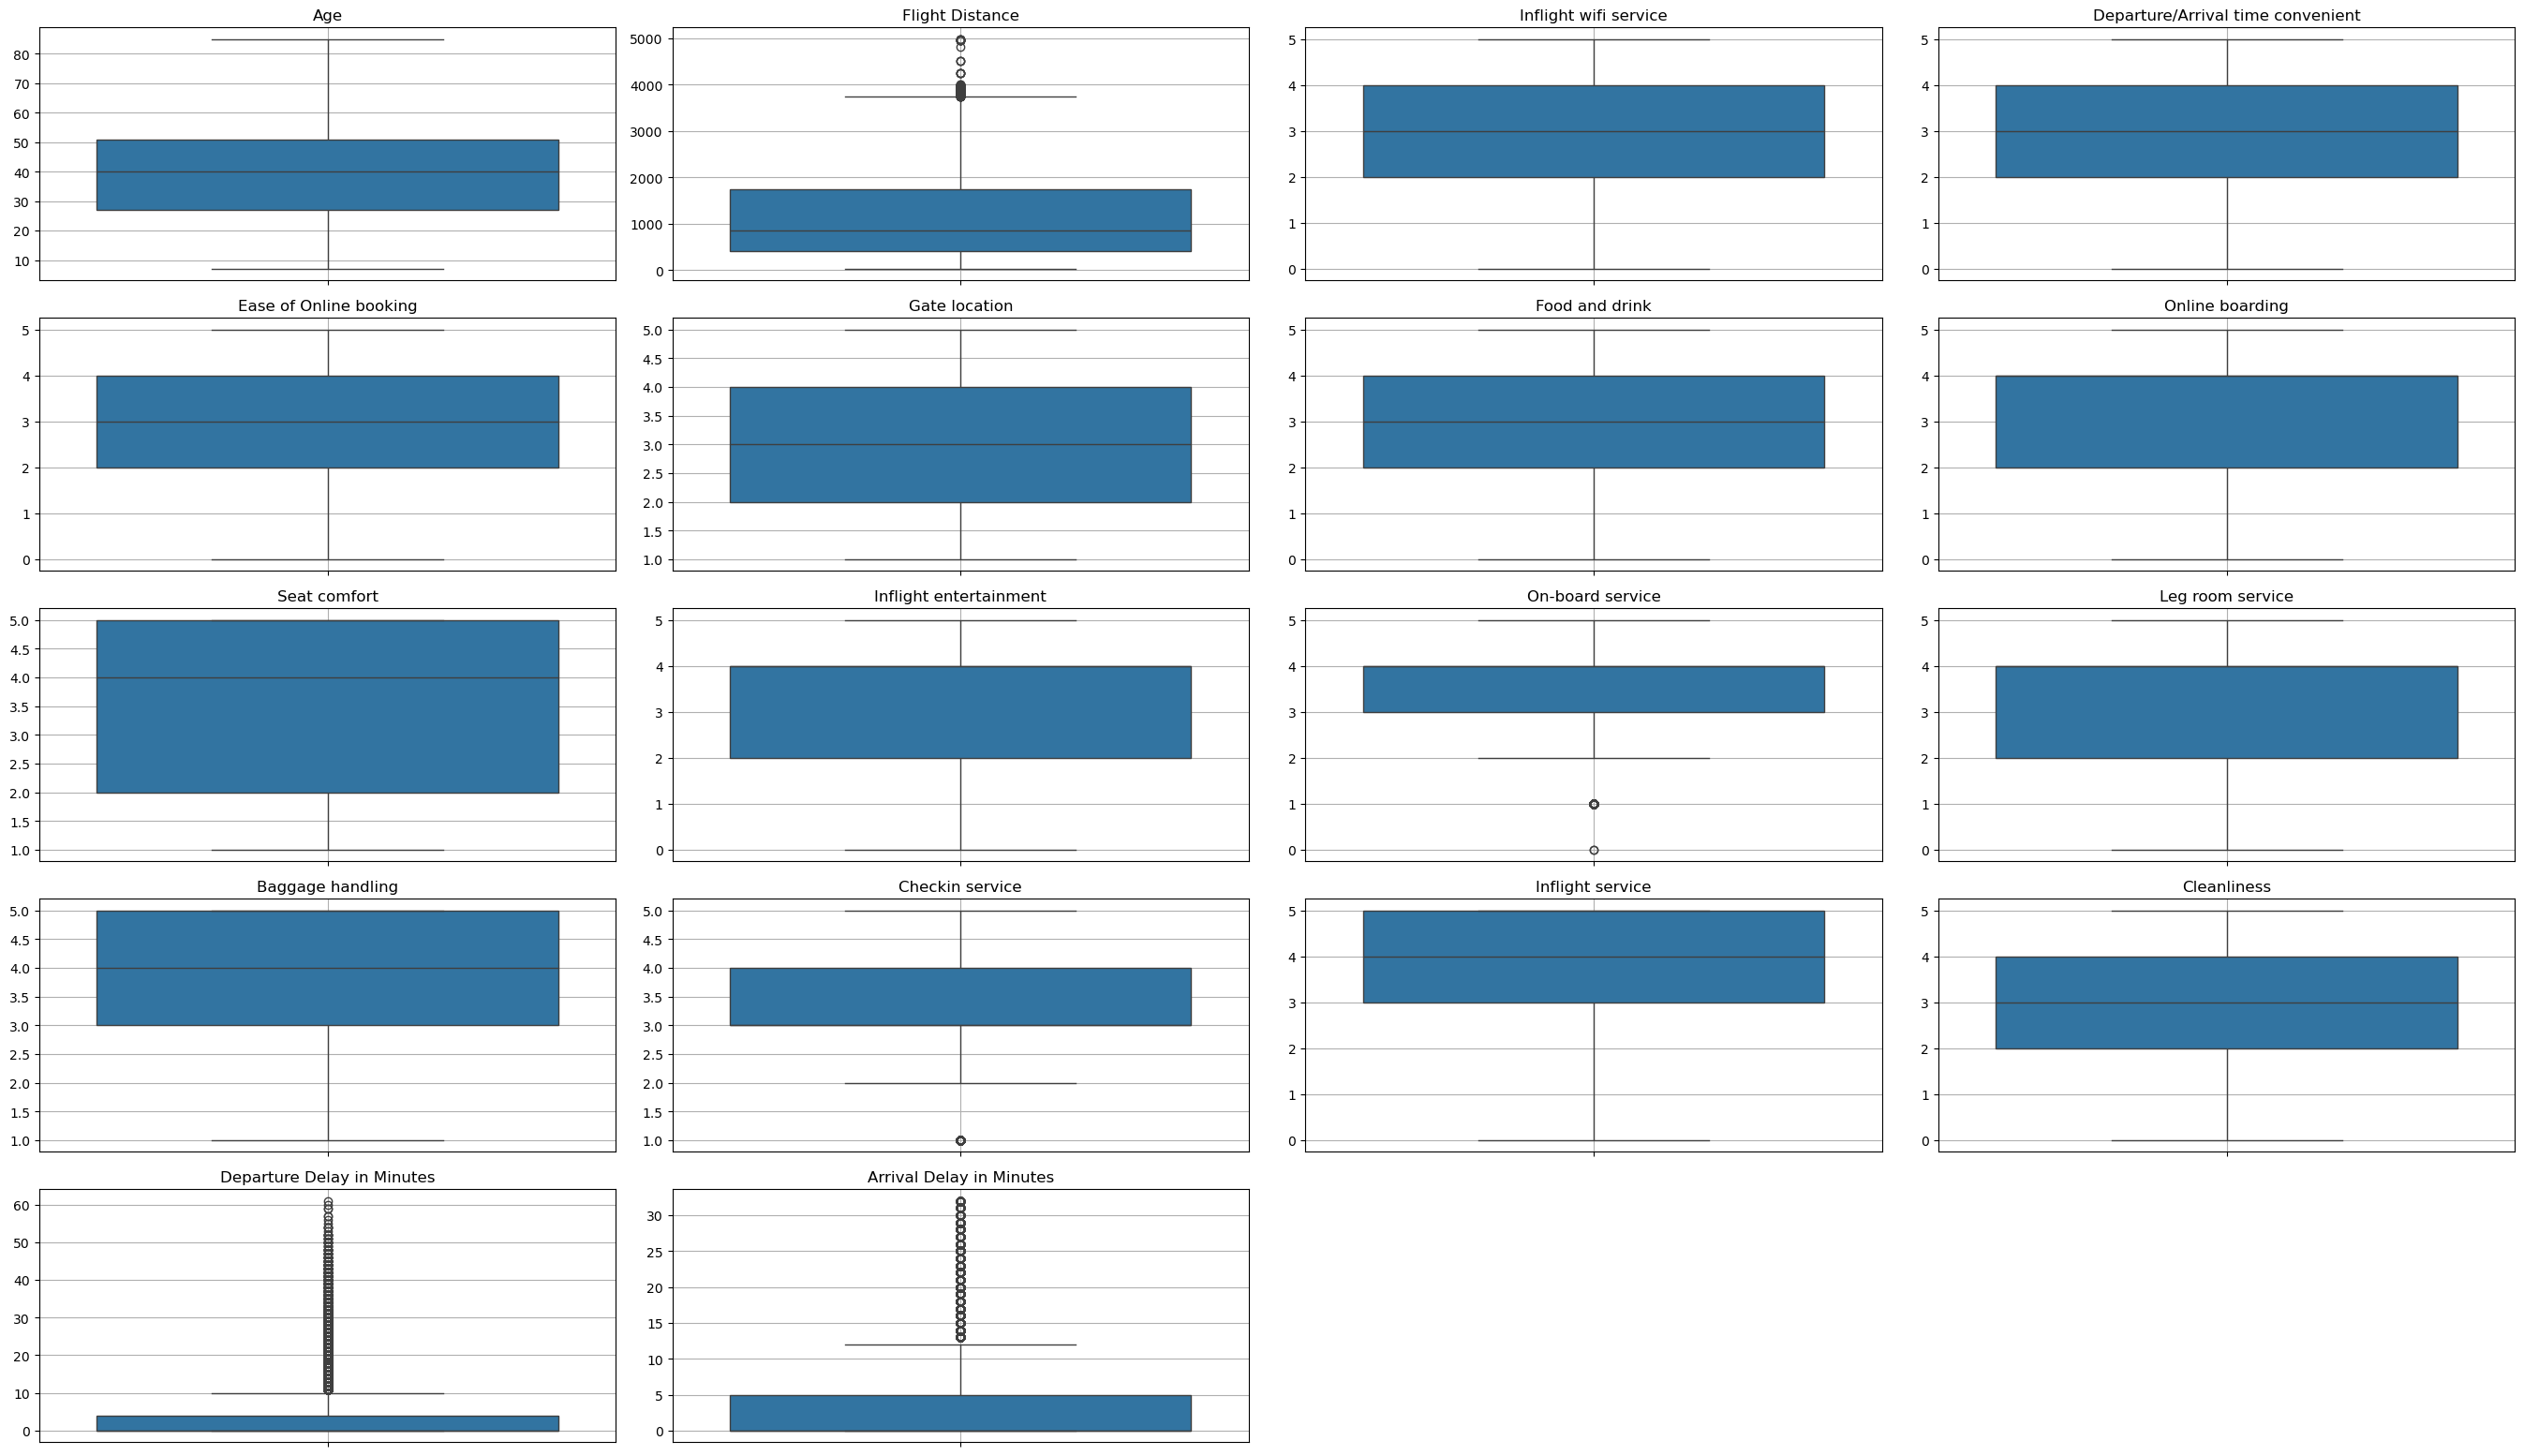

In [18]:
n_cols = 4
n_rows = int(np.ceil(len(num_cols) / 2))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_rows * 3, n_cols * 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df_outlier[col]

    axes[i].set_title(col.replace("_", " "))
    sns.boxplot(y=data, ax=axes[i])
    axes[i].set_ylabel(None)
    axes[i].grid(True)

for j in range(len(num_cols), n_rows * n_cols):
    plt.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [19]:
def oversampling(X, y):
  df = pd.DataFrame(X)
  name = y.to_frame().columns[0]
  df[name] = y
  
  classes = df[name].unique()
#   max_count = df[name].value_counts().max()
  min_count = df[name].value_counts().min() # under sampler
  
  df_balanced = pd.concat([
    df[df[name] == c].sample(min_count, replace=True, random_state=42)
    for c in classes
  ])
  
  return df_balanced

In [20]:
df.columns

Index(['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

# 4. Feature Selection

In [21]:
def LabelEncoder(df: pd.DataFrame):
    unq_map = dict()
    for col in cat_cols:
        unq = df[col].unique()
        unq_map[col] = {v: k for k, v in enumerate(unq)}
        df[col] = df[col].map(unq_map[col])
    
    return df, unq_map

In [22]:
df_enc, struct = LabelEncoder(df_outlier)
df_enc.head().style.set_properties(**df_style).set_table_styles(table_style)

C:\Users\User\AppData\Local\Temp\ipykernel_17984\841440435.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].map(unq_map[col])
C:\Users\User\AppData\Local\Temp\ipykernel_17984\841440435.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].map(unq_map[col])
C:\Users\User\AppData\Local\Temp\ipykernel_17984\841440435.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
1,0,0,36,0,0,2863,1,1,3,1,5,4,5,4,4,4,4,3,4,5,0,0.000000,0
2,1,1,20,0,1,192,2,0,2,4,2,2,2,2,4,1,3,2,2,2,0,0.000000,1
3,1,0,44,0,0,3377,0,0,0,2,3,4,4,1,1,1,1,3,1,4,0,6.000000,0
4,0,0,49,0,1,1182,2,3,4,3,4,1,2,2,2,2,2,4,2,4,0,20.000000,0
5,1,0,16,0,1,311,3,3,3,3,5,5,3,5,4,3,1,1,2,5,0,0.000000,0


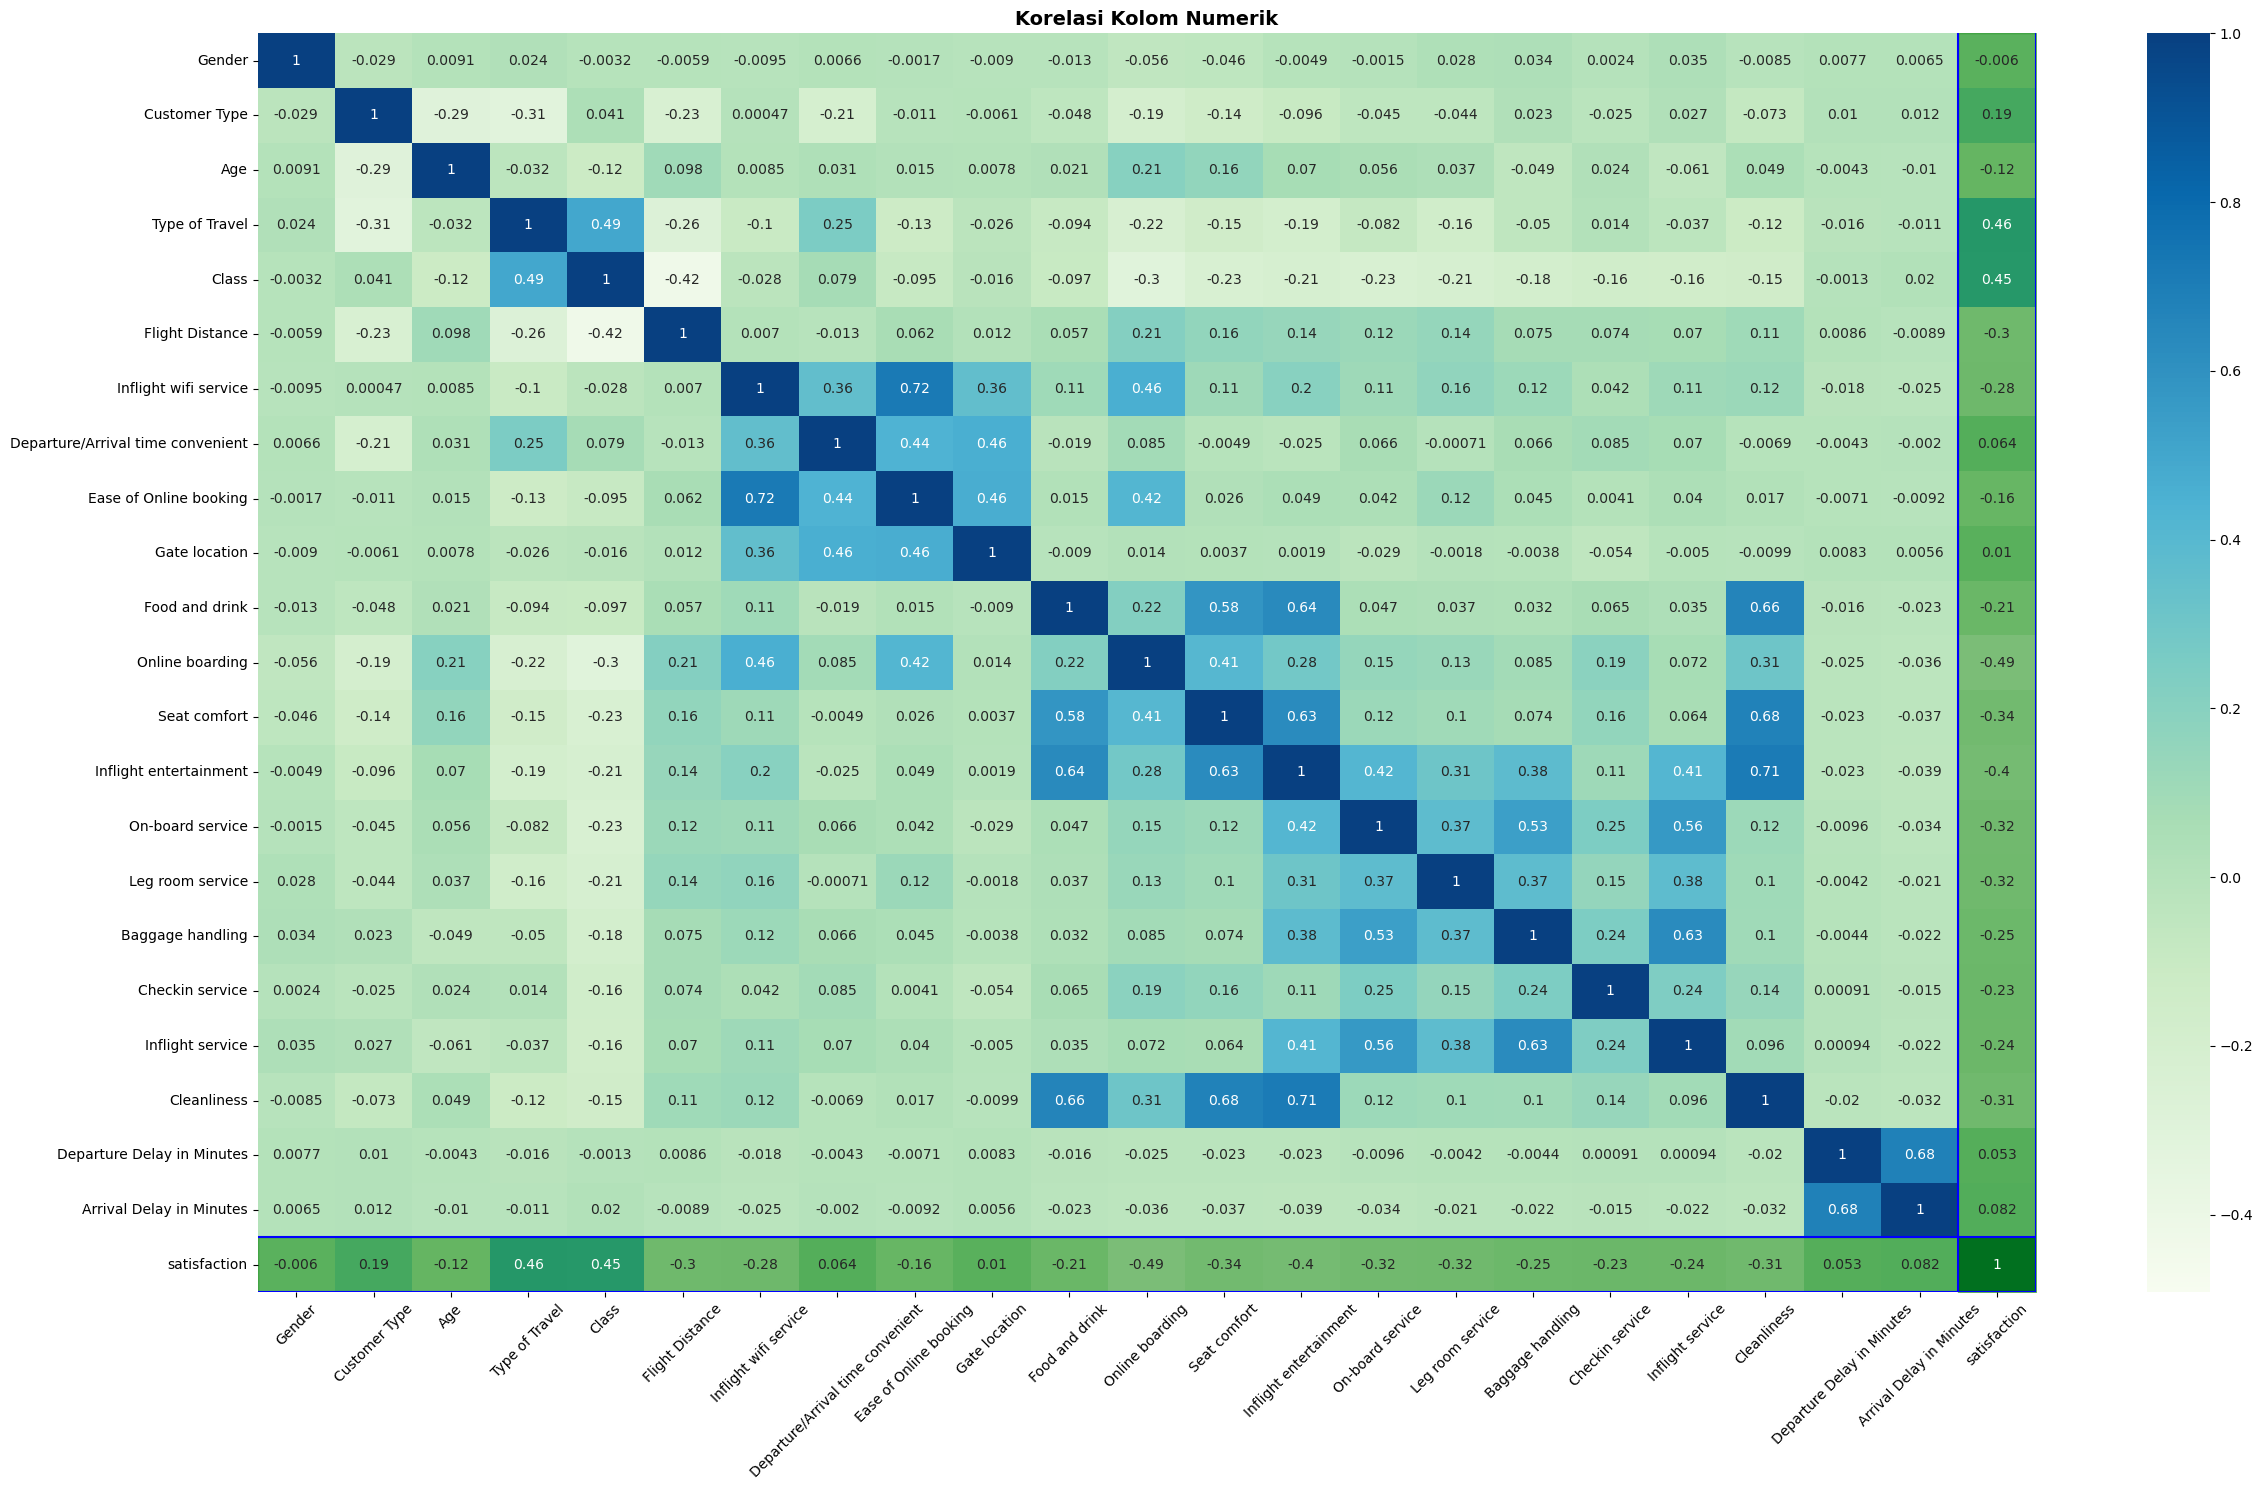

In [23]:
corr = df_enc.corr()
idx = list(corr.columns).index('satisfaction')
plt.figure(figsize=(25, 15))
sns.heatmap(corr, annot=True, cmap='GnBu')

plt.axvline(idx, color='blue', linewidth=1.5)
plt.axvline(idx + 1, color='blue', linewidth=1.5)
plt.fill_betweenx(y=[0, corr.shape[0]], x1=idx, x2=idx+1, color='green', alpha=0.5)

plt.axhline(idx, color='blue', linewidth=1.5)
plt.axhline(idx + 1, color='blue', linewidth=1.5)
plt.fill_between(x=[0, df.shape[0]], y1=idx, y2=idx+1, color='green', alpha=0.5)

plt.title('Korelasi Kolom Numerik', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Mutual Information (MI)

Mutual Information (MI) adalah ukuran dari teori informasi yang digunakan untuk mengukur seberapa besar informasi yang dibagikan antara dua variabel acak \( X \) dan \( Y \). MI mengukur ketergantungan antara dua variabel.

Rumus Umum Mutual Information:

$$
MI(X; Y) = \sum_{x \in X} \sum_{y \in Y} P(x, y) \cdot \log_2 \left( \frac{P(x, y)}{P(x) \cdot P(y)} \right)
$$

Keterangan:
- \( P(x, y) \) : Probabilitas gabungan dari \( x \) dan \( y \)
- \( P(x) \) : Probabilitas marginal dari \( x \)
- \( P(y) \) : Probabilitas marginal dari \( y \)
- \( \log_2 \) : Logaritma basis 2 (karena kita ingin hasil dalam satuan bit)


In [24]:
def mutual_information(x, y, bins=10):
    # Digitalisasi Data dengan np.digitize
    x = np.digitize(x, bins=np.histogram_bin_edges(x, bins=bins))
    y = np.digitize(y, bins=np.histogram_bin_edges(y, bins=bins))

    # Menentukan Jumlah Data (N)
    N = len(x)
    mi = 0

    # Mencari Nilai Unik pada x dan y
    x_values = np.unique(x)
    y_values = np.unique(y)

    # Menghitung Mutual Information
    for xi in x_values:
        for yi in y_values:
            # Menghitung Probabilitas Gabungan 𝑃(𝑥,𝑦)
            p_xy = np.sum((x == xi) & (y == yi)) / N
            if p_xy == 0:
                continue
            # Menghitung Probabilitas Marginal 𝑃(𝑥) dan 𝑃(𝑦)
            p_x = np.sum(x == xi) / N
            p_y = np.sum(y == yi) / N
            # Menghitung Kontribusi MI untuk Setiap Pasangan
            mi += p_xy * np.log2(p_xy / (p_x * p_y))

    return mi

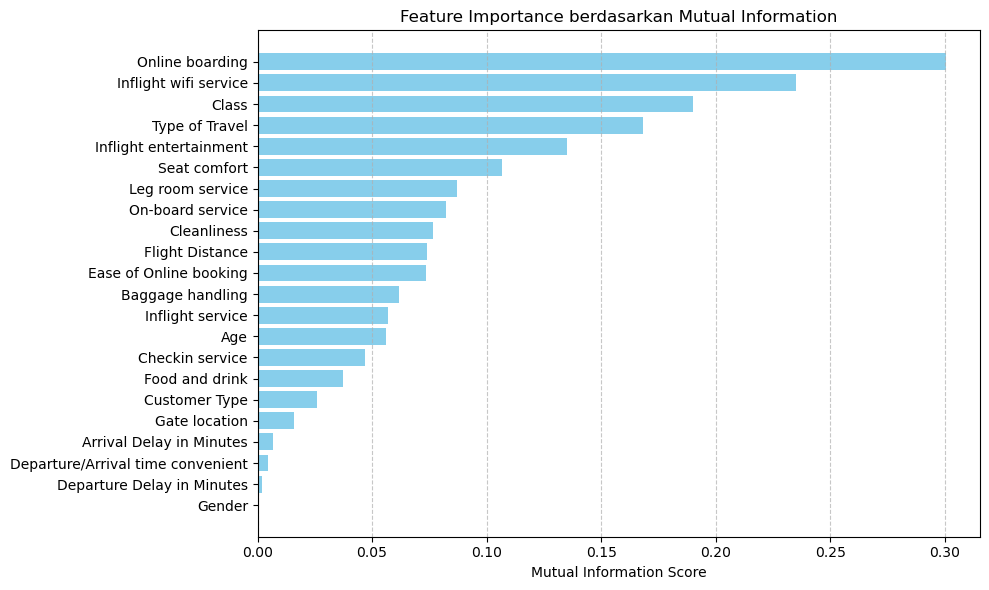

In [25]:
X = df_enc.drop(columns='satisfaction')
y = df_enc['satisfaction']

mi_scores = {col: mutual_information(X[col], y) for col in X.columns}

sorted_mi = sorted(mi_scores.items(), key=lambda x: x[1], reverse=True)
features = [k for k, _ in sorted_mi]
scores = [v for _, v in sorted_mi]

plt.figure(figsize=(10, 6))
bars = plt.barh(features[::-1], scores[::-1], color='skyblue')
plt.xlabel("Mutual Information Score")
plt.title("Feature Importance berdasarkan Mutual Information")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()